In [23]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
seed_list = range(1,6)
scheme_list = ["dringsu2","rrgsu2","ls"]
sw_list = range(40,101,20)

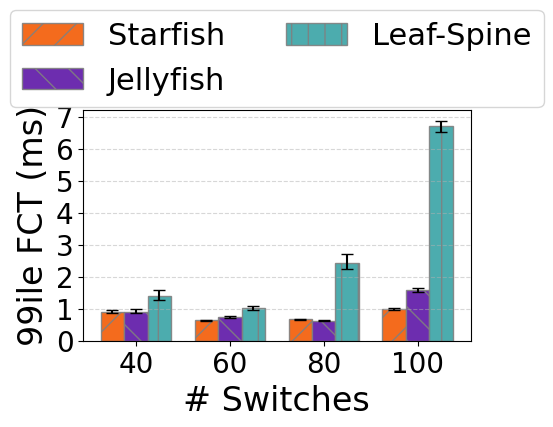

In [19]:
import matplotlib.pyplot as plt
import numpy as np

hatch_patterns = ['/', '\\', '|', '-', '+', 'x', '.', '*']
plotlabeldict = {"dringsu2":"Starfish","rrgsu2":"Jellyfish","ls":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","rrgsu2":"#5d16a6","ls":"#38a3a5"}


# Load data from txt
plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile, 'r') as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        p99 = float(tokens[3])  # 99th percentile FCT
        plotdatadict[outfile] = p99

# Define your schemes, switch counts, and seeds
# scheme_list = ["dringsu2", "rrgsu2", "ls"]
# sw_list = list(range(40, 101, 20))  # [40, 60, 80, 100]
# seed_list = list(range(1, 6))       # [1, 2, 3, 4, 5]

# Prepare data
bar_data = {}  # bar_data[scheme] = list of (mean, lower_err, upper_err) per sw

for scheme in scheme_list:
    stats = []
    for sw in sw_list:
        fct_list = []
        for seed in seed_list:
            outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list.append(p99)
        mean = np.mean(fct_list)
        lower = mean - min(fct_list)
        upper = max(fct_list) - mean
        stats.append((mean, lower, upper))
    bar_data[scheme] = stats

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(5, 3))
bar_width = 0.25
x = np.arange(len(sw_list))
# hatch_patterns = ['/', '\\', 'x']

for i, scheme in enumerate(scheme_list):
    means = [bar_data[scheme][j][0] for j in range(len(sw_list))]
    lower_err = [bar_data[scheme][j][1] for j in range(len(sw_list))]
    upper_err = [bar_data[scheme][j][2] for j in range(len(sw_list))]
    err = [lower_err, upper_err]
    ax.bar(x + i * bar_width, means, bar_width, yerr=err,
           label=plotlabeldict[scheme], color=plotcolordict[scheme], capsize=4, alpha=0.9, hatch=hatch_patterns[i], edgecolor='gray')

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(sw_list)
ax.set_xlabel("# Switches", fontsize=24)
ax.set_ylabel("99ile FCT (ms)", fontsize=24)
# ax.set_title("Grouped Bar Chart of 99th Percentile FCT")
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_yticks(range(8))
ax.tick_params(axis='both', labelsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=2, fontsize=22)
# plt.tight_layout()
plt.savefig(f"eval_scale_supernode.pdf", dpi=600, bbox_inches='tight')


dringsu2: [0.9107358, 0.6402702, 0.6704828, 0.9956200000000001]
rrgsu2: [0.9119420000000001, 0.7289018, 0.6245058, 1.58505]
ls: [1.387832, 1.027989, 2.443978, 6.707544]

In [5]:
dringsu2 = [0.9107358, 0.6402702, 0.6704828, 0.9956200000000001]
rrgsu2 = [0.9119420000000001, 0.7289018, 0.6245058, 1.58505]
ls = [1.387832, 1.027989, 2.443978, 6.707544]

In [7]:
# dring vs leafspine
mysum = 0
for i in range(4):
    mysum += (dringsu2[i] - ls[i]) / ls[i]
print(mysum/4)

# dring vs jellyfish
mysum2 = 0
for i in range(4):
    mysum2 += (dringsu2[i] - rrgsu2[i]) / rrgsu2[i]
print(mysum2/4)

-0.5745399062520429
-0.10529143276412506


In [28]:
dringsu2= [0.9107358, 0.6402702, 0.6704828, 0.9956200000000001, 7.177072]
rrgsu2= [0.9119420000000001, 0.7289018, 0.6245058, 1.58505, 3.1882080000000004]
ls= [1.387832, 1.027989, 2.443978, 6.707544, 18.478559999999995]

In [30]:
# dring vs leafspine
mysum = 0
for i in range(5):
    mysum += (dringsu2[i] - ls[i]) / ls[i]
print(mysum/5)

# dring vs jellyfish
mysum2 = 0
for i in range(5):
    mysum2 += (dringsu2[i] - rrgsu2[i]) / rrgsu2[i]
print(mysum2/5)

-0.5819519326212756
0.16599293690498337


In [27]:
import matplotlib.pyplot as plt
import numpy as np

_sw_list = range(40,121,20)

hatch_patterns = ['/', '\\', '|', '-', '+', 'x', '.', '*']
plotlabeldict = {"dringsu2":"Starfish","rrgsu2":"Jellyfish","ls":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","rrgsu2":"#5d16a6","ls":"#38a3a5"}


# Load data from txt
plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile, 'r') as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        p99 = float(tokens[3])  # 99th percentile FCT
        plotdatadict[outfile] = p99

# Define your schemes, switch counts, and seeds
# scheme_list = ["dringsu2", "rrgsu2", "ls"]
# sw_list = list(range(40, 101, 20))  # [40, 60, 80, 100]
# seed_list = list(range(1, 6))       # [1, 2, 3, 4, 5]

# Prepare data
bar_data = {}  # bar_data[scheme] = list of (mean, lower_err, upper_err) per sw

for scheme in scheme_list:
    stats = []
    for sw in _sw_list:
        fct_list = []
        for seed in seed_list:
            outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list.append(p99)
        mean = np.mean(fct_list)
        lower = mean - min(fct_list)
        upper = max(fct_list) - mean
        stats.append((mean, lower, upper))
    bar_data[scheme] = stats

# Plot grouped bar chart
# fig, ax = plt.subplots(figsize=(5, 3))
bar_width = 0.25
x = np.arange(len(_sw_list))
# hatch_patterns = ['/', '\\', 'x']

for i, scheme in enumerate(scheme_list):
    means = [bar_data[scheme][j][0] for j in range(len(_sw_list))]
    lower_err = [bar_data[scheme][j][1] for j in range(len(_sw_list))]
    upper_err = [bar_data[scheme][j][2] for j in range(len(_sw_list))]
    err = [lower_err, upper_err]
    # ax.bar(x + i * bar_width, means, bar_width, yerr=err,
        #    label=plotlabeldict[scheme], color=plotcolordict[scheme], capsize=4, alpha=0.9, hatch=hatch_patterns[i], edgecolor='gray')

    print(f"{scheme}: {means}")

dringsu2: [0.9107358, 0.6402702, 0.6704828, 0.9956200000000001, 7.177072]
rrgsu2: [0.9119420000000001, 0.7289018, 0.6245058, 1.58505, 3.1882080000000004]
ls: [1.387832, 1.027989, 2.443978, 6.707544, 18.478559999999995]


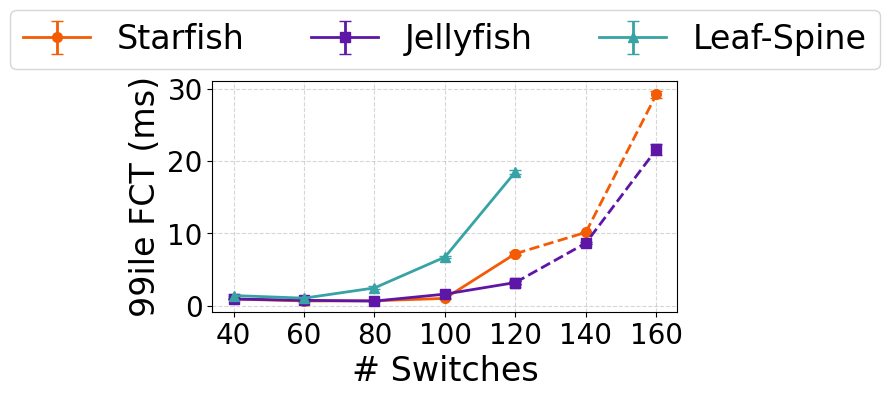

In [21]:
import matplotlib.pyplot as plt
import numpy as np

homedir = "/mnt/mirabelle/az6922_homedir/"
# seed_list = range(1,6)
# scheme_list = ["dringsu2","rrgsu2"]
# sw_list =  [40,161,20]

plotlabeldict_supernode = {
    "dringsu2": "Starfish",
    "rrgsu2": "Jellyfish",
    "ls": "Leaf-Spine"
}

plotlabeldict_ring = {
    "dringsu2": "Starfish",
    "rrgsu2": "Jellyfish",
    "leafspine": "Leaf-Spine"
}

plotcolordict = {
    "dringsu2": "#f35b04",
    "rrgsu2": "#5d16a6",
    "ls": "#38a3a5",
    "leafspine": "#38a3a5"
}

plotmarkerdict = {
    "dringsu2": "o",
    "rrgsu2": "s",
    "ls": "^",
    "leafspine": "^"
}

# Load data
plotdatadict = {}
sumfile = "fct_summary.txt"
with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        p99 = float(tokens[3])
        plotdatadict[outfile] = p99

# Example lists (keep your own if already defined)
# supernode
scheme_list_supernode = ["dringsu2", "rrgsu2", "ls"]
sw_list_supernode = [40, 60, 80, 100,120]
seed_list_supernode = [1, 2, 3, 4, 5]

# ring
scheme_list_ring = ["dringsu2", "rrgsu2", "leafspine"]
sw_list_ring = [120,140,160]
seed_list_ring = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(6, 3))

# -----------------------------
# Supernode lines
# -----------------------------
for scheme in scheme_list_supernode:
    means = []
    lower_err = []
    upper_err = []

    for sw in sw_list_supernode:
        fct_list = []
        for seed in seed_list_supernode:
            outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list.append(p99)

        mean = np.mean(fct_list)
        means.append(mean)
        lower_err.append(mean - min(fct_list))
        upper_err.append(max(fct_list) - mean)

    ax.errorbar(
        sw_list_supernode,
        means,
        yerr=[lower_err, upper_err],
        label=f"{plotlabeldict_supernode[scheme]}",
        color=plotcolordict[scheme],
        marker=plotmarkerdict[scheme],
        linestyle='-',
        linewidth=2,
        markersize=7,
        capsize=4
    )

# -----------------------------
# Ring lines
# -----------------------------
for scheme in scheme_list_ring:
    if scheme == "leafspine": continue
    means = []
    lower_err = []
    upper_err = []

    for sw in sw_list_ring:
        fct_list = []
        for seed in seed_list_ring:
            if sw == 120:
                outfile = f"../eval_scale_larger_supernode/outfiles/{scheme}_sw{sw}_seed{seed}.out"
            else:
                outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"

            p99 = plotdatadict[outfile]
            fct_list.append(p99)

        mean = np.mean(fct_list)
        means.append(mean)
        lower_err.append(mean - min(fct_list))
        upper_err.append(max(fct_list) - mean)

    ax.errorbar(
        sw_list_ring,
        means,
        yerr=[lower_err, upper_err],
        # label=f"{plotlabeldict_ring[scheme]} (Ring)",
        color=plotcolordict[scheme],
        marker=plotmarkerdict[scheme],
        linestyle='--',
        linewidth=2,
        markersize=7,
        capsize=4
    )

# Formatting
ax.set_xlabel("# Switches", fontsize=24)
ax.set_ylabel("99ile FCT (ms)", fontsize=24)
ax.grid(True, axis='both', linestyle='--', alpha=0.5)
ax.tick_params(axis='both', labelsize=20)
ax.set_xticks([40, 60, 80, 100, 120,140,160])
ax.set_xticklabels([40, 60, 80, 100, 120, 140, 160])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=3, fontsize=24)

plt.savefig("eval_scale_line.pdf", dpi=600, bbox_inches='tight')
# plt.show()